In [ ]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict 

e:\Rohanta_AI_workbook\campus_chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

In [3]:
import os
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [4]:
from config.settings import (
    GROQ_API_KEY, GROQ_MODEL,
    LLM_TEMPERATURE, LLM_MAX_TOKENS,
    SYSTEM_PROMPT,
)

In [5]:
llm = ChatGroq(
    model       = GROQ_MODEL,
    temperature = LLM_TEMPERATURE,
    max_tokens  = LLM_MAX_TOKENS,
    api_key     = GROQ_API_KEY,
)

In [6]:
from models.rules_model.rules_extractor import extract_rules

result = extract_rules("Where is the library?")
print(result)

{'intent': 'find_location', 'entities': ['Main Library'], 'category_hints': ['library'], 'nav_pair': None, 'raw_query': 'Where is the library?', 'source': 'rules'}


In [7]:
result['intent']

'find_location'

In [8]:
class BotState(TypedDict):
    # ── Input ──────────────────────────────────────────────
    query:          str        # raw user query

    # ── After extract_node ─────────────────────────────────
    intent:         str        
    entities:       list[dict] 
    category_hints: list[str]  
    nav_pair:       dict | None  

    # ── After search_node ──────────────────────────────────
    kb_results:     list[dict] # matched KB entries
    kb_context:     str        # formatted text for LLM prompt
    is_list_mode:   bool       # True when returning all results for count/list queries

    # ── After llm_node ─────────────────────────────────────
    answer:         str        # final bot response
   

In [9]:
def intent_entity_extraction(state:BotState):
    query = state['query']
    result = extract_rules("query")

    return {'intent': result['intent'],'entities': result['entities'],'category_hints':result['category_hints'],'nav_pair':result['nav_pair']}
    

In [10]:
from __future__ import annotations
import json
import re
from pathlib import Path
from rapidfuzz import fuzz
from config.settings import KB_PATH, KB_TOP_N, KB_SCORE_THRESHOLD, KB_NAV_THRESHOLD

# ---------------------------------------------------------------------------
# Load and index KB
# ---------------------------------------------------------------------------

def _load_kb(path: Path = KB_PATH) -> list[dict]:
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    for entry in data:
        entry["_search_text"] = " ".join(filter(None, [
            entry.get("name", ""),
            entry.get("description", ""),
            entry.get("category", ""),
            entry.get("map_reference", ""),
            entry.get("department", ""),
            entry.get("room_number", ""),
            entry.get("nearby_landmarks", ""),
        ])).lower()
    return data


_KB: list[dict] = _load_kb()

# ---------------------------------------------------------------------------
# List query detection
# ---------------------------------------------------------------------------
_LIST_PATTERNS = [
    r"\bhow many\b", r"\ball\b", r"\blist\b",
    r"\bcount\b",    r"\btotal\b", r"\bevery\b", r"\bshow all\b",
]

def is_list_query(query: str) -> bool:
    q = query.lower()
    return any(re.search(pat, q) for pat in _LIST_PATTERNS)

# ---------------------------------------------------------------------------
# Scoring
# ---------------------------------------------------------------------------

def _score_entry(entry: dict, query_lower: str,
                 entity_texts: list[str], category_hints: list[str]) -> float:
    score      = 0.0
    name_lower = entry.get("name", "").lower()
    st         = entry["_search_text"]

    if query_lower in name_lower or name_lower in query_lower:
        score += 80
    for ent in entity_texts:
        if ent.lower() in name_lower:   score += 60
        elif ent.lower() in st:         score += 20
    if entry.get("category") in category_hints:
        score += 40
    score += fuzz.token_set_ratio(query_lower, name_lower) * 0.3
    for word in re.findall(r"\w+", query_lower):
        if len(word) > 3 and word in st:
            score += 5

    return score

# ---------------------------------------------------------------------------
# Public search API
# ---------------------------------------------------------------------------

def search_by_category(category_hints: list[str]) -> list[dict]:
    """Return ALL KB entries matching any of the given categories."""
    return [e for e in _KB if e.get("category") in category_hints]


def search(extracted: dict,
           top_n: int = KB_TOP_N,
           score_threshold: float = KB_SCORE_THRESHOLD) -> list[dict]:
    """Scored search — returns top_n best matching KB entries."""
    query_lower    = extracted["raw_query"].lower()
    entity_texts   = [e["text"] for e in extracted.get("entities", [])]
    category_hints = extracted.get("category_hints", [])

    scored = []
    for entry in _KB:
        s = _score_entry(entry, query_lower, entity_texts, category_hints)
        if s >= score_threshold:
            scored.append({**entry, "_score": round(s, 2)})

    scored.sort(key=lambda x: x["_score"], reverse=True)
    return scored[:top_n]


def search_single(query_text: str, category_hints: list[str],
                  top_n: int = 1,
                  score_threshold: float = KB_NAV_THRESHOLD) -> list[dict]:
    """
    Search for a single location text (used in navigation node).
    Lower default threshold since location names are short.
    """
    extracted = {
        "raw_query":      query_text,
        "entities":       [],
        "category_hints": category_hints,
    }
    return search(extracted, top_n=top_n, score_threshold=score_threshold)


def smart_search(extracted: dict,
                 default_top_n: int = KB_TOP_N) -> tuple[list[dict], bool]:
    """
    Auto-detect list/count queries and switch to category-wide search.
    Returns (results, is_list_mode).
    """
    query          = extracted["raw_query"]
    category_hints = extracted.get("category_hints", [])

    if is_list_query(query) and category_hints:
        return search_by_category(category_hints), True

    return search(extracted, top_n=default_top_n), False

# ---------------------------------------------------------------------------
# Context formatter
# ---------------------------------------------------------------------------

def format_kb_context(results: list[dict], intent: str,
                      is_list_mode: bool = False) -> str:
    if not results:
        return "No matching locations found in the campus knowledge base."

    lines = []

    if is_list_mode:
        lines.append(f"Total found: {len(results)}\n")
        for i, r in enumerate(results, 1):
            line = f"{i}. {r['name']}"
            if r.get("map_reference"): line += f" — {r['map_reference']}"
            if r.get("department"):    line += f" ({r['department']})"
            lines.append(line)
    else:
        for i, r in enumerate(results, 1):
            lines.append(f"[Result {i}] {r['name']} (category: {r['category']})")
            lines.append(f"  Map reference : {r.get('map_reference', 'N/A')}")
            lines.append(f"  Description   : {r.get('description', 'N/A')}")
            lines.append(f"  Directions    : {r.get('directions_from_entrance', 'N/A')}")

            hours = r.get("opening_hours", {})
            if hours:
                hours_str = ", ".join(f"{d}: {h}" for d, h in hours.items())
                lines.append(f"  Opening hours : {hours_str}")

            events = r.get("events", [])
            if events:
                lines.append(f"  Events        : {'; '.join(events)}")

            if r.get("nearby_landmarks"):
                lines.append(f"  Nearby        : {r['nearby_landmarks']}")

            if r.get("directions_by_floor"):
                floor_str = " | ".join(f"{k}: {v}" for k, v in r["directions_by_floor"].items())
                lines.append(f"  By floor      : {floor_str}")

            lines.append("")

    return "\n".join(lines)


def location_summary(entry: dict) -> str:
    """Compact summary of a KB entry for navigation prompts."""
    parts = [entry.get("name", "Unknown")]
    if entry.get("floor") is not None:
        parts.append(f"Floor: {entry['floor']}")
    if entry.get("map_reference"):
        parts.append(f"Location: {entry['map_reference']}")
    if entry.get("directions_from_entrance"):
        parts.append("Directions from entrance: " + entry["directions_from_entrance"])
    if entry.get("nearby_landmarks"):
        parts.append("Nearby: " + entry["nearby_landmarks"])
    return "\n  ".join(parts)

In [11]:
CATEGORY_KEYWORDS: dict[str, list[str]] = {
    "library":             ["library", "books", "reading", "journal", "study"],
    "cafeteria":           ["cafeteria", "canteen", "food", "eat", "meal", "lunch", "dinner", "breakfast", "dining"],
    "gym":                 ["gym", "fitness", "sports", "yoga", "workout", "exercise", "basketball"],
    "it_lab":              ["it lab", "computer lab", "pc", "workstation", "programming lab"],
    "lecture_hall":        ["lecture hall", "auditorium", "hall", "lecture"],
    "student_union":       ["student union", "union", "lounge", "games room"],
    "admin_office":        ["admission", "registry", "enrollment", "transcript", "id card"],
    "career_center":       ["career", "job", "internship", "cv", "placement"],
    "medical_center":      ["medical", "health", "clinic", "doctor", "nurse", "pharmacy"],
    "department":          ["department", "dept"],
    "hod_office":          ["hod", "head of department"],
    "seminar_room":        ["seminar room", "seminar"],
    "classroom":           ["classroom", "class room"],
    "lab":                 ["lab", "laboratory"],
    "printing_room":       ["print", "photocopy", "xerox"],
    "security_office":     ["security", "guard"],
    "outdoor":             ["garden", "parking", "park", "outdoor"],
    "teachers_room":       ["teacher", "faculty", "staff room"],
    "engineering_college": ["engineering block", "engineering college", "engg"],
    "auditorium":          ["auditorium"],
}

def extract_category_hints(query: str) -> list[str]:
    q = query.lower()
    return [cat for cat, kws in CATEGORY_KEYWORDS.items() if any(kw in q for kw in kws)]

In [12]:
def kb_search(state: BotState):
    extracted = {
        "intent":         state["intent"],
        "entities":       state["entities"],
        "category_hints": state["category_hints"],
        "nav_pair":       state["nav_pair"],
        "raw_query":      state["query"],
    }

    # ── Navigation: search source and destination separately ──
    if state["intent"] == "navigation" and state.get("nav_pair"):
        nav      = state["nav_pair"]
        src_text = nav["source"]
        dst_text = nav["destination"]

        src_r = search_single(src_text, extract_category_hints(src_text))
        dst_r = search_single(dst_text, extract_category_hints(dst_text))

        src_block = location_summary(src_r[0]) if src_r else f"'{src_text}' not found in KB"
        dst_block = location_summary(dst_r[0]) if dst_r else f"'{dst_text}' not found in KB"

        kb_context   = f"Starting location:\n  {src_block}\n\nDestination:\n  {dst_block}"
        kb_results   = (src_r or []) + (dst_r or [])
        is_list_mode = False

    # ── Regular / list query ──
    else:
        kb_results, is_list_mode = smart_search(extracted)
        kb_context = format_kb_context(kb_results, state["intent"], is_list_mode)

    return {
        **state,
        "kb_results":   kb_results,
        "kb_context":   kb_context,
        "is_list_mode": is_list_mode,
    }


In [13]:
def final_ans_generation(state: BotState):
    user_content = state['query']
    messages     = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=user_content),
    ]
    response = llm.invoke(messages)
    answer   = response.content.strip()


    return {"answer":      answer}


In [14]:
graph = StateGraph(BotState)

graph.add_node("intent_entity_extraction",intent_entity_extraction)
graph.add_node("kb_search",kb_search)
graph.add_node("final_ans_generation",final_ans_generation)

graph.add_edge(START,"intent_entity_extraction")
graph.add_edge("intent_entity_extraction","kb_search")
graph.add_edge("kb_search","final_ans_generation")
graph.add_edge("final_ans_generation",END)

workflow = graph.compile()

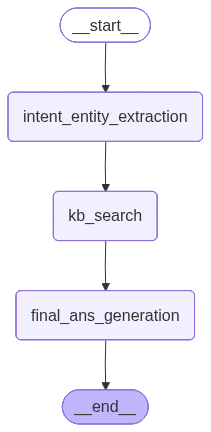

In [15]:
workflow

In [16]:
initial_state = {
    'query': "Where is the library?"
}



In [ ]:
workflow.invoke({
    'query': "Where is the library?"
})["answer"]

"The library is located in the University Hall building, which is situated on the north side of campus. To get there, follow these steps:\n\n1. Start at the Student Union building.\n2. Head east towards the quad.\n3. Continue walking past the Student Union building and the cafeteria.\n4. Turn left at the University Hall sign.\n5. Enter the building through the main entrance.\n6. Take the elevator or stairs to the 2nd floor, where the library is located.\n\nThe University Hall building is easily recognizable by its large clock tower. You can't miss it."

In [18]:
queries = [
    "Where is the IT lab?",
    "What time does the library close on Friday?",
    "Are there any events at the Student Union?",
    "Tell me about the cafeteria",
    "How do I go from civil department to mechanical department?",
    "How many departments are there?",
    "it lab where",
    "canteen food timings",
]

for q in queries:
    ans = workflow.invoke({'query':q})["answer"]
    print('*'*50)
    print(q)
    print(ans)


**************************************************
Where is the IT lab?
The IT lab is located in the University Library Building (Building 12). You can find it on the 2nd floor, near the east wing. It's adjacent to the library's study area.
**************************************************
What time does the library close on Friday?
The library's hours are as follows: 
Monday to Thursday: 8am - 10pm
Friday: 8am - 8pm
Saturday: 10am - 6pm
Sunday: 12pm - 10pm

The library closes at 8pm on Friday.
**************************************************
Are there any events at the Student Union?
Yes, there is an event at the Student Union. The event is a Career Fair, and it will take place on Thursday, June 1st, from 10:00 AM to 2:00 PM.
**************************************************
Tell me about the cafeteria
The cafeteria is located in the University Center Building, which is on the first floor. You can access it by entering the building through the main entrance and turning left. The c